In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Powerplant_dataset.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT -> temperature
# V -> vacccum
# AP -> pressure
# RH -> humidity
# PE -> produced energy

In [5]:
df.shape

(9568, 5)

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

###  Steps for Implementing ANN for Regression :- 
![alt text](../Theory/image/ANN_Regression.png)

In [9]:
# Split our data 
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [12]:
import torch 
import torch.nn as nn

In [13]:
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)


In [14]:
type(X_train_scaled)

numpy.ndarray

In [15]:
type(y_train)
y_train.shape

(7654,)

In [16]:
y_train_tensor.shape

torch.Size([7654, 1])

![alt text](../Theory/image/001_Architectural_Breakdown.png)

> Data Loader class takes help from Tensor datasetclass to load the data in batches or all at once.
> Data Loader class cannot directly load the data, it needs to be passed through Tensor dataset class first.  
![alt text](../Theory/image/09_DataLoader_01.png)

In [17]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [18]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = 32)
test_loader = DataLoader(test_dataset,batch_size=32)

# DEEP LEARNING

In [19]:
# define   our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            #nn.Linear(in_features=,out_features)
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            
             # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # Output layer
            nn.Linear(6,1),
    
        )
    def forward(self,x):
        return self.model(x)

In [20]:
import torch.optim as optim
model = ANN()

# loss,optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [24]:
# Train the ANN

train_losses = []
val_losses = []

best_val_loss = float('inf')

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total running loss for 1 epoch
    
    for xb,yb in train_loader :
        # xb = features of 1 batch
        # yb = labels of 1 batch

        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop... predicted output for this batch
        loss = criterion(outputs,yb) # compute loss
        loss.backward() # back prop.. compute gradiests
        ## How does Backprop happend and its steps

        # Update the parametrs 
        optimizer.step() # params update

        running_loss+=loss.item() #loss is a tensor ->  python float

        
        
    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation 
    running_val_loss = 0.0

    model.eval()
    with torch.no_grad(): # no grading Compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss+=loss.item()
        epoch_val_loss = running_val_loss/len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss= {epoch_val_loss}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(),"best_model.pt") # .pt or .pth 

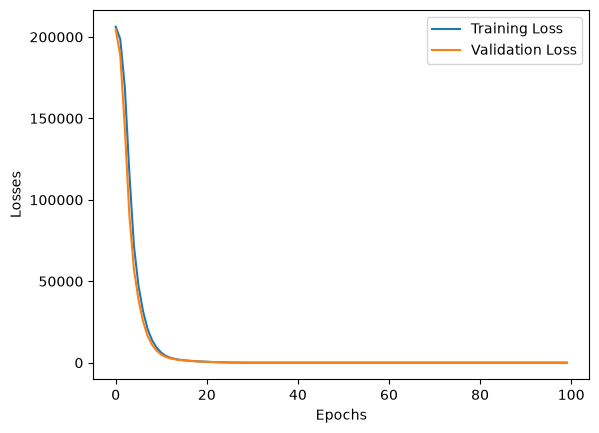

In [22]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss" :val_losses
})

plt.plot(loss_df["Training Loss"],label = "Training Loss") 
plt.plot(loss_df["Validation Loss"],label = "Validation Loss") 

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()

In [28]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [30]:
# Evaluate our model
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds,y_train_tensor)
    test_mse_loss = criterion(test_preds,y_test_tensor)

print("Training MSE: ",train_mse_loss.item())
print("Testing MSE: ",test_mse_loss.item())

Training MSE:  21.167390823364258
Testing MSE:  19.5213565826416


In [34]:
from sklearn.metrics import r2_score
print("r^2 Score : ",r2_score(y_test,test_preds))

r^2 Score :  0.9317778951775006


In [36]:
predicted_df = pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values ,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis = 1)

,Predicted Values,Actual Values
0,435.734924,433.27
1,437.002716,438.16
2,461.504700,458.42
3,476.099701,480.82
4,435.946167,441.41
...,...,...
1909,451.319336,456.70
1910,431.941772,438.04
1911,467.676788,467.80
1912,431.353577,437.14
